# 06 — Supervised: Price Imputation + Affluence Drivers

Two honest supervised uses of the feature store:

1. **Impute the missing residential prices** (`res_avg_buy`, present for ~55% of localities) with a LightGBM
   regressor, **cross-validated** and **benchmarked against a city-mean baseline** so we only trust the
   model if it beats geography alone. Imputed values are flagged `price_is_imputed` — real values are never
   overwritten.
2. **Driver analysis with SHAP** — what actually predicts affluence (metro access, IT employers, amenities…).

**Leakage guard:** every price-derived feature (buy/rent ranges, ratios, spread, affluence tier) is excluded
from the predictors. LightGBM handles missing feature values natively, so no feature imputation is needed.

Reads `artifacts/localities_segmented.parquet`; writes `artifacts/features_imputed.parquet` + `shap_drivers.png`.

In [1]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore")

ART = Path.cwd() / "artifacts"
df = pd.read_parquet(ART / "localities_segmented.parquet").reset_index(drop=True)
print("Rows:", len(df), "| price present:", int(df["res_avg_buy"].notna().sum()),
      "| missing:", int(df["res_avg_buy"].isna().sum()))

Rows: 1001 | price present: 549 | missing: 452


In [2]:
# --- Build the predictor matrix (NO price-derived features) ---
NUM_FEATS = [
    "num_educational_institute", "num_hospital", "num_shopping_centre", "num_transportation_hub",
    "num_commercial_hub", "num_tourist_spot", "num_nearby_localities",
    "total_amenities", "amenity_diversity", "infra_completeness", "retail_civic_balance",
    "num_employers", "primary_sector_score",
    "sector_information_technology", "sector_finance_and_banking", "sector_consulting",
    "sector_manufacturing_and_industry", "sector_government_and_public_sector",
    "sector_retail_and_commercial", "sector_healthcare_and_pharma",
    "airport_min", "dist_to_city_centroid_km", "knn_density_km",
    "graph_degree", "graph_pagerank", "graph_clustering", "belt_size",
]
NUM_FEATS = [c for c in NUM_FEATS if c in df.columns]
CAT_FEATS = ["ADDRESS", "maturity"]

X = df[NUM_FEATS].apply(pd.to_numeric, errors="coerce").copy()
X["is_metro_connected"] = df["is_metro_connected"].astype(float)
for c in CAT_FEATS:
    X[c] = df[c].astype("category")

y = df["res_avg_buy"]
present = y.notna()
assert not any(("buy" in c or "rent" in c or "price" in c or "affluence" in c) for c in X.columns), "leak!"
print("Predictors:", X.shape[1], "(", len(NUM_FEATS) + 1, "numeric +", len(CAT_FEATS), "categorical )")

Predictors: 30 ( 28 numeric + 2 categorical )


In [3]:
# --- Cross-validated LightGBM vs city-mean baseline ---
from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error

Xp, yp = X[present], y[present].values
cities = df.loc[present, "ADDRESS"].values

model = LGBMRegressor(n_estimators=400, learning_rate=0.03, num_leaves=31,
                      subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof = cross_val_predict(model, Xp, yp, cv=kf)
r2, mae = r2_score(yp, oof), mean_absolute_error(yp, oof)

# city-mean baseline (out-of-fold, same splits)
base = np.empty(len(yp))
for tr, te in kf.split(Xp):
    means = pd.Series(yp[tr]).groupby(cities[tr]).mean()
    gm = yp[tr].mean()
    base[te] = [means.get(cities[te[i]], gm) for i in range(len(te))]
r2b, maeb = r2_score(yp, base), mean_absolute_error(yp, base)

print(f"LightGBM (features) : R2 = {r2:.3f} | MAE = Rs {mae:,.0f}/sqft")
print(f"City-mean baseline  : R2 = {r2b:.3f} | MAE = Rs {maeb:,.0f}/sqft")
print("--> features add signal beyond geography:", "YES" if r2 > r2b else "NO (use baseline)")

LightGBM (features) : R2 = 0.515 | MAE = Rs 4,907/sqft
City-mean baseline  : R2 = 0.492 | MAE = Rs 5,035/sqft
--> features add signal beyond geography: YES


Top 12 affluence drivers (mean |SHAP|):
ADDRESS                          5220.5
primary_sector_score             1073.9
dist_to_city_centroid_km          972.1
sector_retail_and_commercial      877.3
belt_size                         748.0
num_educational_institute         729.7
sector_information_technology     506.4
sector_healthcare_and_pharma      499.0
retail_civic_balance              485.2
amenity_diversity                 379.6
maturity                          371.7
sector_consulting                 365.0


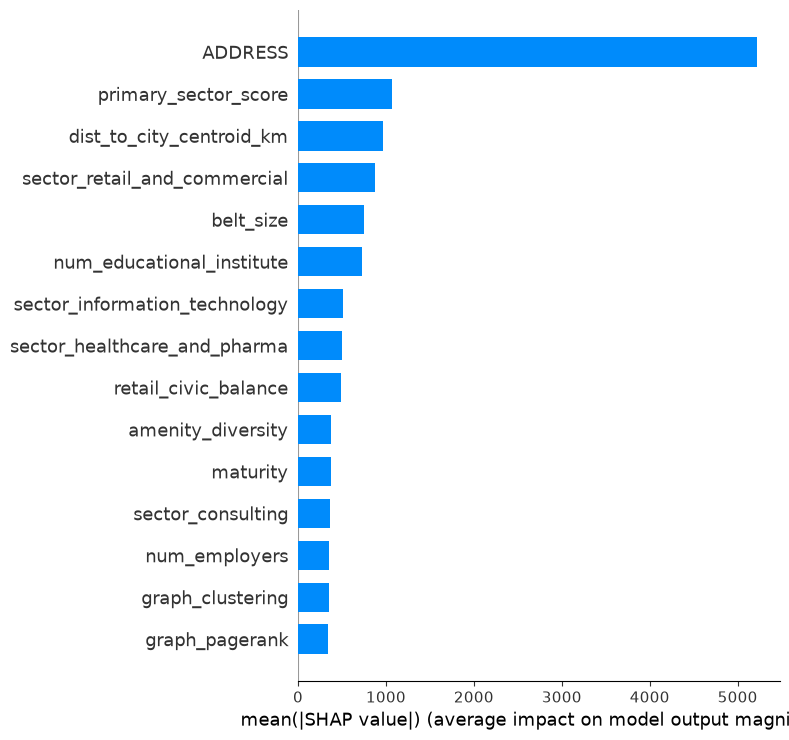


Saved SHAP plot -> artifacts/shap_drivers.png


In [4]:
# --- SHAP driver analysis (fit on all present data) ---
import shap
import matplotlib.pyplot as plt

model.fit(Xp, yp)
explainer = shap.TreeExplainer(model)
sv = explainer.shap_values(Xp)

imp = pd.Series(np.abs(sv).mean(axis=0), index=Xp.columns).sort_values(ascending=False)
print("Top 12 affluence drivers (mean |SHAP|):")
print(imp.head(12).round(1).to_string())

plt.figure()
shap.summary_plot(sv, Xp, plot_type="bar", max_display=15, show=False)
plt.tight_layout()
plt.savefig(ART / "shap_drivers.png", dpi=110, bbox_inches="tight")
plt.show()
print("\nSaved SHAP plot -> artifacts/shap_drivers.png")

In [5]:
# --- Impute the missing prices (real values kept; predictions flagged) ---
df["res_avg_buy_imputed"] = df["res_avg_buy"]
missing = ~present
df.loc[missing, "res_avg_buy_imputed"] = model.predict(X[missing]).round(0)
df["price_is_imputed"] = missing.values

print("Imputed", int(missing.sum()), "missing prices.")
print(f"Real    avg Rs {df.loc[present, 'res_avg_buy'].mean():,.0f}/sqft | "
      f"Imputed avg Rs {df.loc[missing, 'res_avg_buy_imputed'].mean():,.0f}/sqft")

out = ART / "features_imputed.parquet"
df.to_parquet(out, index=False)
print("\nSaved", df.shape[0], "rows x", df.shape[1], "cols ->", out.relative_to(Path.cwd()))

Imputed 452 missing prices.
Real    avg Rs 14,625/sqft | Imputed avg Rs 11,935/sqft

Saved 1001 rows x 78 cols -> artifacts\features_imputed.parquet


## Output
`artifacts/features_imputed.parquet` + `shap_drivers.png` — a complete, model-imputed affluence column
(`res_avg_buy_imputed` + `price_is_imputed` flag) and a SHAP ranking of what drives price.

**Honesty note:** imputation is only trustworthy if the cross-validated R² beats the city-mean baseline
(printed above). With ~550 training rows, treat imputed prices as *directional* — the `price_is_imputed`
flag lets every downstream consumer weight them accordingly.

**Next:** `07_similarity_anomaly_synthesis.ipynb` — lookalike engine, hidden-gem anomaly detection, and the
ML-recomputed GOAT-Fit, consolidated into the master feature store.